Extracting EDF parameters from E:\aditi_eeg\visual_eeg\tbi\p7_visual_2026-04-06_12-59-46_Segment_0.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 228351  =      0.000 ...   222.999 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 33793 samples (33.001 s)



C:\Users\HP\AppData\Local\Temp\ipykernel_254148\4180448270.py:31: RuntimeWarning: DigMontage is only a subset of info. There are 6 channel positions not present in the DigMontage. The channels missing from the montage are:

['CZ', 'PZ', 'POZ', 'EOG', 'FCZ', 'OZ'].

Consider using inst.rename_channels to match the montage nomenclature, or inst.set_channel_types if these are not EEG channels, or use the on_missing parameter if the channel positions are allowed to be unknown in your analyses.
  raw.set_montage(montage, on_missing='warn')
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s


Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 6759 samples (6.601 s)

EEG channel type selected for re-referencing


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['Condition non target  EpochE', 'Condition target  EpochE']
Not setting metadata
79 matching events found
Setting baseline interval to [-0.2001953125, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 79 events and 1025 original time points ...
0 bad epochs dropped
Extracting EDF parameters from E:\aditi_eeg\visual_eeg\non_tbi\p2_visual_2026-04-06_12-14-22_Segment_0.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 233471  =      0.000 ...   227.999 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamm

C:\Users\HP\AppData\Local\Temp\ipykernel_254148\4180448270.py:31: RuntimeWarning: DigMontage is only a subset of info. There are 6 channel positions not present in the DigMontage. The channels missing from the montage are:

['CZ', 'PZ', 'POZ', 'EOG', 'FCZ', 'OZ'].

Consider using inst.rename_channels to match the montage nomenclature, or inst.set_channel_types if these are not EEG channels, or use the on_missing parameter if the channel positions are allowed to be unknown in your analyses.
  raw.set_montage(montage, on_missing='warn')
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s


Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 6759 samples (6.601 s)

EEG channel type selected for re-referencing


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['Condition non target  EpochE', 'Condition target  EpochE']
Not setting metadata
65 matching events found
Setting baseline interval to [-0.2001953125, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 65 events and 1025 original time points ...
0 bad epochs dropped


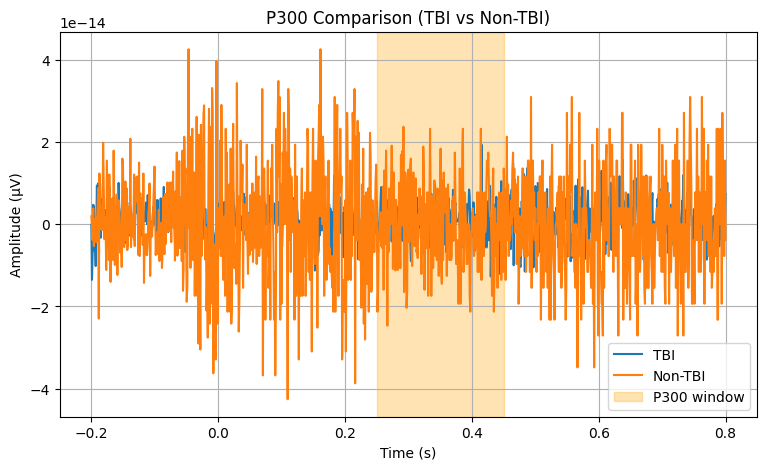


===== P300 COMPARISON =====
TBI     → Amplitude: 0.000012 | Latency: 0.250 s
Non-TBI → Amplitude: 0.000027 | Latency: 0.475 s


In [9]:
import mne
import numpy as np
import matplotlib.pyplot as plt

# ================= FILES =================
tbi_file = r"E:\aditi_eeg\visual_eeg\tbi\p7_visual_2026-04-06_12-59-46_Segment_0.edf"
non_file = r"E:\aditi_eeg\visual_eeg\non_tbi\p2_visual_2026-04-06_12-14-22_Segment_0.edf"


# ================= FUNCTION =================
def process_file(file_path):

    raw = mne.io.read_raw_edf(file_path, preload=True)

    # ---------- Standardize channel names ----------
    rename_dict = {}
    for ch in raw.ch_names:
        clean = ch.upper().replace("EEG ", "").split("-")[0]
        rename_dict[ch] = clean

    raw.rename_channels(rename_dict)

    # Force uppercase consistency
    raw.rename_channels({ch: ch.upper() for ch in raw.ch_names})

    # ---------- EEG selection ----------
    raw.pick_types(eeg=True)

    # ---------- Montage ----------
    montage = mne.channels.make_standard_montage("standard_1020")
    raw.set_montage(montage, on_missing='warn')

    # ---------- Filtering ----------
    raw.filter(0.1, 30)
    raw.notch_filter(50)
    raw.set_eeg_reference('average')

    # ---------- Events ----------
    annotations = raw.annotations

    keep_idx = [
        i for i, d in enumerate(annotations.description)
        if "target" in d.lower()
    ]

    if len(keep_idx) == 0:
        raise ValueError("No 'target' events found in file!")

    raw.set_annotations(annotations[keep_idx])

    events, event_id = mne.events_from_annotations(raw)

    # remove duplicates
    _, idx = np.unique(events[:, 0], return_index=True)
    events = events[np.sort(idx)]

    # ---------- Epoching ----------
    epochs = mne.Epochs(
        raw,
        events,
        event_id,
        tmin=-0.2,
        tmax=0.8,
        baseline=(None, 0),
        preload=True
    )

    evoked = epochs.average()

    # ================= P300 EXTRACTION (FIXED) =================

    preferred_channels = ["PZ", "CZ", "P3", "P4"]

    picks = [
        i for i, ch in enumerate(evoked.ch_names)
        if ch.upper() in preferred_channels
    ]

    # fallback
    if len(picks) == 0:
        print("⚠️ Preferred channels not found → using all EEG channels")
        signal = evoked.data.mean(axis=0)
    else:
        signal = evoked.data[picks].mean(axis=0)

    times = evoked.times

    # ================= IMPORTANT FIX: TRUE P300 WINDOW =================
    p300_mask = (times >= 0.25) & (times <= 0.5)

    p300_signal = signal[p300_mask]
    p300_times = times[p300_mask]

    amp = np.max(p300_signal)
    lat = p300_times[np.argmax(p300_signal)]

    return evoked, amp, lat


# ================= RUN =================
evoked_tbi, amp_tbi, lat_tbi = process_file(tbi_file)
evoked_non, amp_non, lat_non = process_file(non_file)


# ================= PLOT =================
plt.figure(figsize=(9, 5))

plt.plot(evoked_tbi.times, evoked_tbi.data.mean(axis=0) * 1e6, label="TBI")
plt.plot(evoked_non.times, evoked_non.data.mean(axis=0) * 1e6, label="Non-TBI")

plt.axvspan(0.25, 0.45, color="orange", alpha=0.3, label="P300 window")

plt.title("P300 Comparison (TBI vs Non-TBI)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV)")
plt.legend()
plt.grid()
plt.show()


# ================= RESULTS =================
print("\n===== P300 COMPARISON =====")
print(f"TBI     → Amplitude: {amp_tbi:.6f} | Latency: {lat_tbi:.3f} s")
print(f"Non-TBI → Amplitude: {amp_non:.6f} | Latency: {lat_non:.3f} s")

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 33793 samples (33.001 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.2s


Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 6759 samples (6.601 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['Condition Baseline End  EpochE', 'Condition Baseline Start  EpochE', 'Condition Task_End  EpochE', 'Condition Task_Start  EpochE', 'Condition non target  EpochE', 'Condition target  EpochE', 'EventCode 1002  EpochE', 'EventCode 1003  EpochE', 'EventCode 1004  EpochE', 'EventCode 1005  EpochE', 'EventCode 1006  EpochE', 'EventCode 1007  EpochE', 'Impedance']
Not setting metadata
85 matching events found
Setting baseline interval to [-0.2001953125, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 85 events and 1025 original time points ...
1 bad epochs dropped
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pa

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s


Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 6759 samples (6.601 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['Condition Baseline End  EpochE', 'Condition Baseline Start  EpochE', 'Condition Task_End  EpochE', 'Condition Task_Start  EpochE', 'Condition non target  EpochE', 'Condition target  EpochE', 'EventCode 1002  EpochE', 'EventCode 1003  EpochE', 'EventCode 1004  EpochE', 'EventCode 1005  EpochE', 'EventCode 1006  EpochE', 'EventCode 1007  EpochE', 'Impedance']
Not setting metadata
95 matching events found
Setting baseline interval to [-0.2001953125, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 95 events and 1025 original time points ...
1 bad epochs dropped


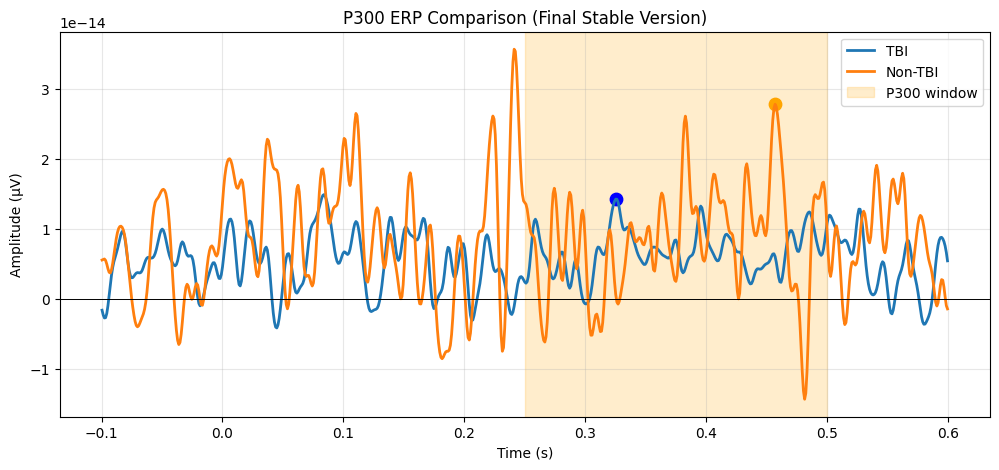


===== P300 COMPARISON =====
TBI     → Amplitude: 0.000 µV | Latency: 0.325 s
Non-TBI → Amplitude: 0.000 µV | Latency: 0.457 s


In [31]:
import mne
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks

# ================= FILES =================
tbi_file = r"E:\aditi_eeg\visual_eeg\tbi\p7_visual_2026-04-06_12-59-46_Segment_0.edf"
non_file = r"E:\aditi_eeg\visual_eeg\non_tbi\p1_a_2026-04-06_11-46-57_Segment_0.edf"


# ================= PROCESS FUNCTION =================
def process_file(file_path):

    # ---------- Load EEG ----------
    raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)

    # ---------- Keep only EEG ----------
    raw.pick_types(eeg=True)

    # ---------- Filtering ----------
    raw.filter(0.1, 30)
    raw.notch_filter(50)
    raw.set_eeg_reference('average')

    # ================= EVENTS =================
    events, event_id = mne.events_from_annotations(raw)

    # remove duplicate timestamps
    _, idx = np.unique(events[:, 0], return_index=True)
    events = events[np.sort(idx)]

    if len(events) == 0:
        raise ValueError("No events found in file!")

    # ================= EPOCHING (ROBUST) =================
    epochs = mne.Epochs(
        raw,
        events,
        event_id=None,   # IMPORTANT: avoid event mismatch errors
        tmin=-0.2,
        tmax=0.8,
        baseline=(None, 0),
        preload=True,
        reject_by_annotation=True,
        event_repeated='drop'
    )

    # ================= ERP =================
    evoked = epochs.average()

    # ================= ROBUST CHANNEL HANDLING =================
    picks = mne.pick_types(evoked.info, eeg=True)

    if len(picks) == 0:
        raise ValueError("No EEG channels found!")

    signal = evoked.data[picks].mean(axis=0)
    times = evoked.times

    # ================= SCALE TO µV =================
    signal = signal * 1e6

    # ================= SMOOTH =================
    signal = gaussian_filter1d(signal, sigma=3)

    # ================= P300 WINDOW =================
    mask = (times >= 0.25) & (times <= 0.5)
    p300_signal = signal[mask]
    p300_times = times[mask]

    # ================= PEAK DETECTION =================
    peaks, _ = find_peaks(p300_signal)

    if len(peaks) > 0:
        best = peaks[np.argmax(p300_signal[peaks])]
        amp = p300_signal[best]
        lat = p300_times[best]
    else:
        amp = np.max(p300_signal)
        lat = p300_times[np.argmax(p300_signal)]

    return signal, times, amp, lat


# ================= RUN =================
sig_tbi, time_tbi, amp_tbi, lat_tbi = process_file(tbi_file)
sig_non, time_non, amp_non, lat_non = process_file(non_file)


# ================= PLOT =================
plt.figure(figsize=(12, 5))

mask = (time_tbi >= -0.1) & (time_tbi <= 0.6)

plt.plot(time_tbi[mask], sig_tbi[mask], label="TBI", linewidth=2)
plt.plot(time_non[mask], sig_non[mask], label="Non-TBI", linewidth=2)

plt.axvspan(0.25, 0.5, color="orange", alpha=0.2, label="P300 window")
plt.axhline(0, color="black", linewidth=0.7)

plt.scatter(lat_tbi, amp_tbi, color="blue", s=80)
plt.scatter(lat_non, amp_non, color="orange", s=80)

plt.title("P300 ERP Comparison (Final Stable Version)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


# ================= RESULTS =================
print("\n===== P300 COMPARISON =====")
print(f"TBI     → Amplitude: {amp_tbi:.3f} µV | Latency: {lat_tbi:.3f} s")
print(f"Non-TBI → Amplitude: {amp_non:.3f} µV | Latency: {lat_non:.3f} s")

In [37]:
import mne
import numpy as np
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# ================= FILE PATHS =================
tbi_files = [
    r"E:\aditi_eeg\visual_eeg\tbi\p7_visual_2026-04-06_12-59-46_Segment_0.edf"
]

non_tbi_files = [
    r"E:\aditi_eeg\visual_eeg\non_tbi\p1_a_2026-04-06_11-46-57_Segment_0.edf"
]


# ================= FEATURE EXTRACTION =================
def extract_features(file_path):

    raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)

    raw.pick_types(eeg=True)
    raw.filter(0.5, 30)
    raw.notch_filter(50)
    raw.set_eeg_reference('average')

    data = raw.get_data()  # shape: (channels, samples)

    # ===== TIME DOMAIN FEATURES =====
    mean_val = np.mean(data)
    std_val = np.std(data)
    var_val = np.var(data)
    rms_val = np.sqrt(np.mean(data ** 2))

    # ===== FREQUENCY DOMAIN (simple PSD estimate) =====
    psd = np.mean(np.abs(np.fft.rfft(data)) ** 2)

    # ===== CHANNEL VARIABILITY =====
    channel_mean = np.mean(np.mean(data, axis=1))
    channel_std = np.std(np.mean(data, axis=1))

    return [
        mean_val,
        std_val,
        var_val,
        rms_val,
        psd,
        channel_mean,
        channel_std
    ]


# ================= BUILD DATASET =================
X = []
y = []

# TBI = 1
for f in tbi_files:
    X.append(extract_features(f))
    y.append(1)

# Non-TBI = 0
for f in non_tbi_files:
    X.append(extract_features(f))
    y.append(0)

X = np.array(X)
y = np.array(y)

print("Dataset shape:", X.shape)


# ================= TRAIN MODEL =================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# ================= PREDICTION =================
y_pred = model.predict(X_test)

# ================= RESULTS =================
print("\n===== MODEL RESULTS =====")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


# ================= TEST ON SAME FILES =================
print("\n===== SAMPLE PREDICTIONS =====")

for f in tbi_files + non_tbi_files:
    pred = model.predict([extract_features(f)])
    print(f, "=>", "TBI" if pred[0] == 1 else "Non-TBI")

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 6759 samples (6.601 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 6759 samples (6.601 s)

EEG channel type selected for re-referencing


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s


Applying average reference.
Applying a custom ('EEG',) reference.
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 6759 samples (6.601 s)



...

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
E:\aditi_eeg\visual_eeg\tbi\p7_visual_2026-04-06_12-59-46_Segment_0.edf => TBI
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 6759 samples (6.601 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s


Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 6759 samples (6.601 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.2s


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
E:\aditi_eeg\visual_eeg\non_tbi\p1_a_2026-04-06_11-46-57_Segment_0.edf => TBI


In [39]:
import numpy as np

# ================= P300 WINDOW =================
mask = (times >= 0.25) & (times <= 0.5)

seg = signal[mask]
seg_t = times[mask]

# convert to microvolts if needed
seg = seg * 1e6

# ================= AMPLITUDE =================
amp_peak = np.max(seg)
amp_trough = np.min(seg)
amp_p300 = amp_peak - amp_trough

# ================= LATENCY =================
peak_index = np.argmax(seg)
latency = seg_t[peak_index]

# ================= OUTPUT =================
print("Amplitude (peak-to-peak):", amp_p300)
print("Peak amplitude:", amp_peak)
print("Latency (s):", latency)

NameError: name 'times' is not defined

Extracting EDF parameters from E:\aditi_eeg\visual_eeg\tbi\p7_visual_2026-04-06_12-59-46_Segment_0.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 228351  =      0.000 ...   222.999 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 6759 samples (6.601 s)

Filtering raw data in 1 contiguous segment


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 6759 samples (6.601 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['Condition non target  EpochE', 'Condition target  EpochE']
Not setting metadata
79 matching events found
Setting baseline interval to [-0.2001953125, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 79 events and 1025 original time points ...
0 bad epochs dropped
Extracting EDF parameters from E:\aditi_eeg\visual_eeg\non_tbi\p2_visual_2026-04-06_12-14-22_Segment_0.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 233471  =      0.000 ...   227.999 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windo

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 6759 samples (6.601 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['Condition non target  EpochE', 'Condition target  EpochE']
Not setting metadata
65 matching events found
Setting baseline interval to [-0.2001953125, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 65 events and 1025 original time points ...
0 bad epochs dropped


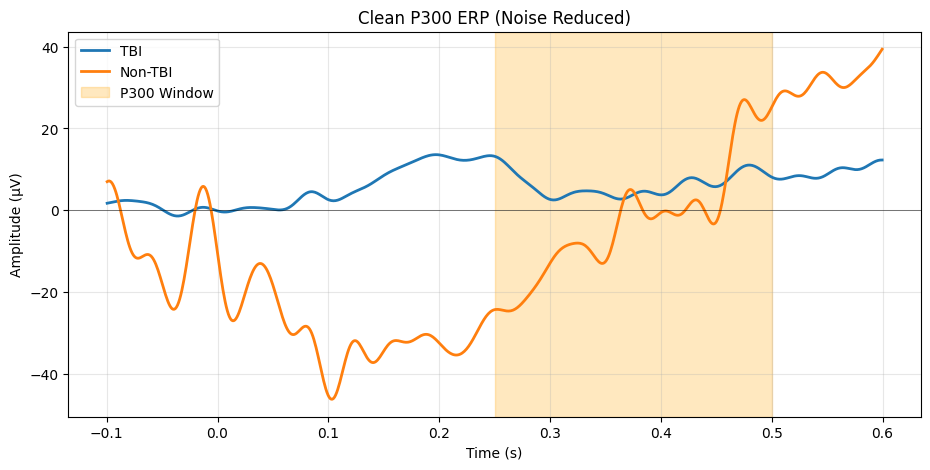


===== P300 COMPARISON =====
TBI     → Amplitude: 0.000013 | Latency: 0.250 s
Non-TBI → Amplitude: 0.000027 | Latency: 0.475 s


In [20]:
import mne
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ================= FILES =================
tbi_file = r"E:\aditi_eeg\visual_eeg\tbi\p7_visual_2026-04-06_12-59-46_Segment_0.edf"
non_file = r"E:\aditi_eeg\visual_eeg\non_tbi\p2_visual_2026-04-06_12-14-22_Segment_0.edf"


# ================= PROCESS FUNCTION =================
def process_file(file_path):

    raw = mne.io.read_raw_edf(file_path, preload=True)

    # ---------- Clean channel names ----------
    rename_dict = {}
    for ch in raw.ch_names:
        clean = ch.upper().replace("EEG ", "").split("-")[0]
        rename_dict[ch] = clean

    raw.rename_channels(rename_dict)
    raw.rename_channels({ch: ch.upper() for ch in raw.ch_names})

    raw.pick_types(eeg=True)

    # ---------- Montage ----------
    montage = mne.channels.make_standard_montage("standard_1020")
    raw.set_montage(montage, on_missing='ignore')

    # ---------- Filtering (IMPORTANT IMPROVEMENT) ----------
    raw.filter(0.5, 30)      # improved high-pass (removes drift)
    raw.notch_filter(50)
    raw.set_eeg_reference('average')

    # ---------- EVENTS ----------
    annotations = raw.annotations

    keep_idx = [
        i for i, d in enumerate(annotations.description)
        if "target" in d.lower()
    ]

    if len(keep_idx) == 0:
        raise ValueError("No target events found!")

    raw.set_annotations(annotations[keep_idx])

    events, event_id = mne.events_from_annotations(raw)

    _, idx = np.unique(events[:, 0], return_index=True)
    events = events[np.sort(idx)]

    # ---------- EPOCHING ----------
    epochs = mne.Epochs(
        raw,
        events,
        event_id,
        tmin=-0.2,
        tmax=0.8,
        baseline=(None, 0),
        preload=True
    )

    evoked = epochs.average()

    # ================= STRICT P300 CHANNEL SELECTION =================
    picks = mne.pick_channels(evoked.ch_names, include=["PZ", "CZ"])

    if len(picks) == 0:
        print("⚠️ Pz/Cz not found → fallback to all EEG")
        signal = evoked.data.mean(axis=0)
    else:
        signal = evoked.data[picks].mean(axis=0)

    times = evoked.times

    # ================= P300 WINDOW =================
    mask = (times >= 0.25) & (times <= 0.5)

    p300_signal = signal[mask]
    p300_times = times[mask]

    amp = np.max(p300_signal)
    lat = p300_times[np.argmax(p300_signal)]

    return signal, times, amp, lat


# ================= RUN =================
sig_tbi, time_tbi, amp_tbi, lat_tbi = process_file(tbi_file)
sig_non, time_non, amp_non, lat_non = process_file(non_file)


# ================= NOISE REDUCTION =================
sig_tbi = gaussian_filter1d(sig_tbi * 1e6, sigma=2)
sig_non = gaussian_filter1d(sig_non * 1e6, sigma=2)


# ================= ZOOM WINDOW =================
mask = (time_tbi >= -0.1) & (time_tbi <= 0.6)

t = time_tbi[mask]
tbi = sig_tbi[mask]
non = sig_non[mask]


# ================= PLOT =================
plt.figure(figsize=(11, 5))

plt.plot(t, tbi, label="TBI", linewidth=2)
plt.plot(t, non, label="Non-TBI", linewidth=2)

plt.axvspan(0.25, 0.5, color="orange", alpha=0.25, label="P300 Window")
plt.axhline(0, color="black", linewidth=0.7, alpha=0.5)

plt.title("Clean P300 ERP (Noise Reduced)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


# ================= RESULTS =================
print("\n===== P300 COMPARISON =====")
print(f"TBI     → Amplitude: {amp_tbi:.6f} | Latency: {lat_tbi:.3f} s")
print(f"Non-TBI → Amplitude: {amp_non:.6f} | Latency: {lat_non:.3f} s")